In [64]:
from utils import CLIP
import os
import pickle
os.chdir('/home/jetson/cmap')
clip = CLIP('ViT-B-16-SigLIP')
text_features = {}
text_list = ['umbrella', 'fire extinguisher', 'a single traffic cone', 'luggage', 'rc car', 'pile of traffic cone']
text_features['list'] = text_list
for text in text_list:
    text_features[text] = clip.encode_text([text])
os.chdir('/home/jetson/cmap/athirdmapper')
with open('text_features.pkl', 'wb') as f:
    pickle.dump(text_features, f)
print(text_list)

['umbrella', 'fire extinguisher', 'a single traffic cone', 'luggage', 'rc car', 'pile of traffic cone']


In [65]:
import pickle
import numpy as np
import torch
import torch.nn.functional as F
with open('features.pkl', 'rb') as file:
    features = pickle.load(file)
with open('features_ind.pkl', 'rb') as file:
    features_ind = pickle.load(file)
with open('text_features.pkl', 'rb') as file:
    text_features = pickle.load(file)
print(text_features['list'])

['umbrella', 'fire extinguisher', 'a single traffic cone', 'luggage', 'rc car', 'pile of traffic cone']


In [66]:
text_feature = text_features['a single traffic cone']
def similarity(image_features, text_features):
    if torch.cuda.is_available(): 
        return image_features @ text_features.cpu().numpy().T
    return image_features @ text_features.numpy().T
similarities = similarity(features, text_feature).squeeze()*100
# get softmax
similarities_s = F.softmax(torch.tensor(similarities), dim=0).numpy()
similarities_s
M_s = np.max(similarities_s)
m_s = np.min(similarities_s)
nsim = np.zeros_like(similarities_s)
nsim[similarities_s > 0.01] = 1
m = int(np.sum(nsim))
# nsim[similarities_s < 0.01] = 0
# n = int(np.sum(nsim))
print(M_s, m_s, m)

import numpy as np
sim_sort_ind = np.argsort(similarities, axis=0)[::-1]
sim_sort_ind = sim_sort_ind[:m]

0.11378294669021284 7.20185235033742e-10 23


/tmp/ipykernel_28093/711615417.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(i)


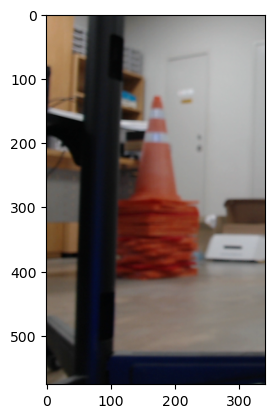

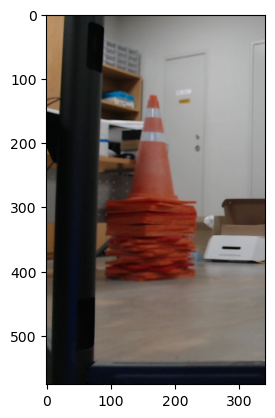

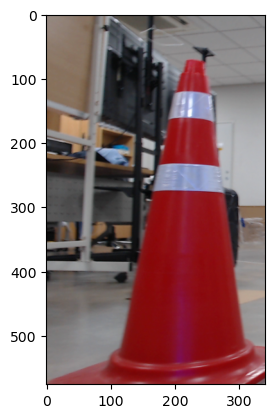

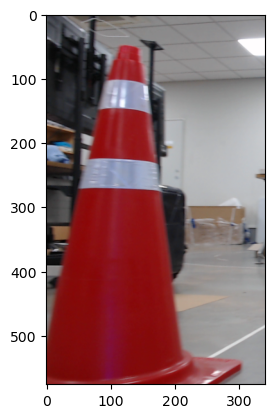

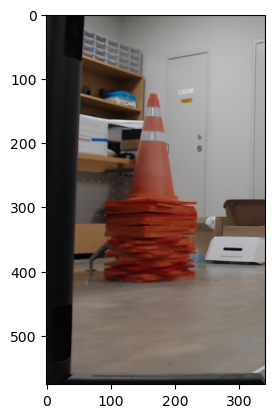

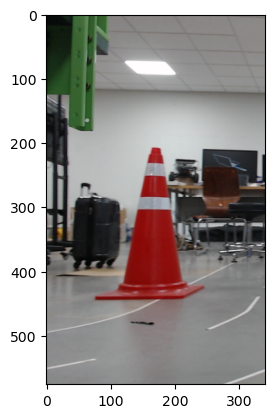

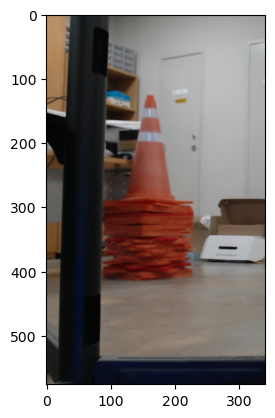

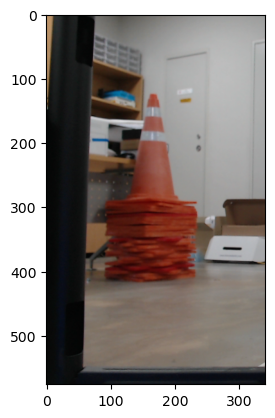

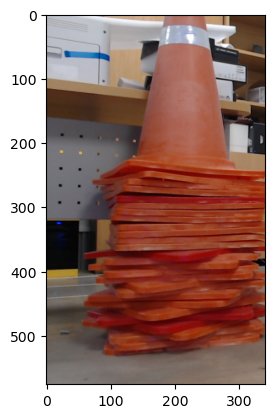

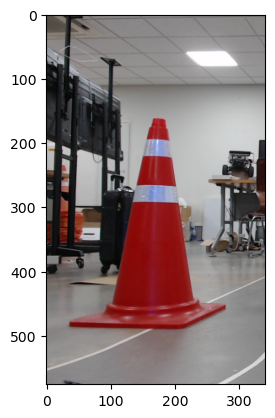

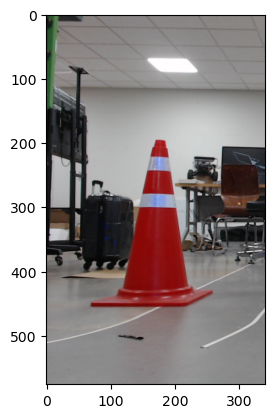

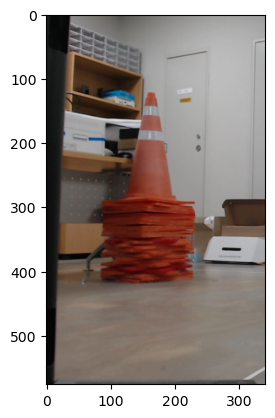

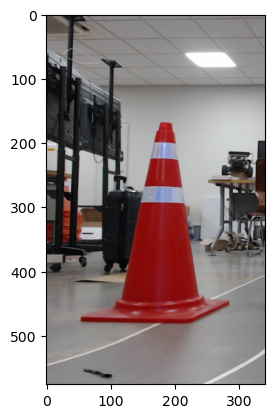

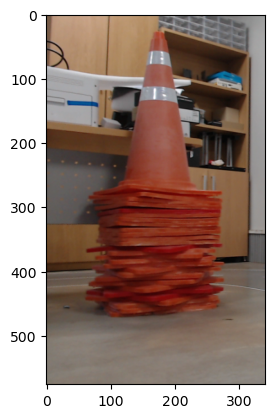

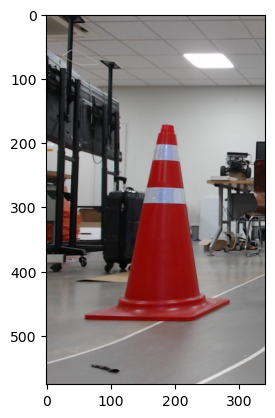

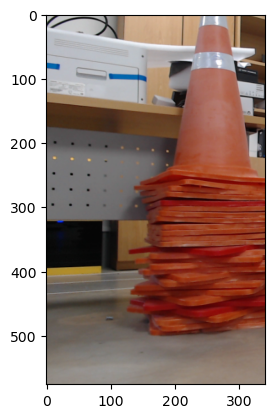

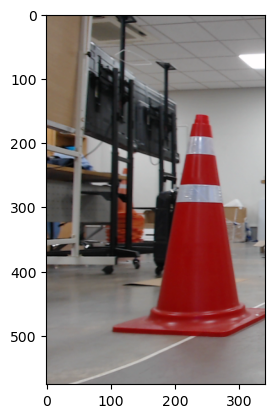

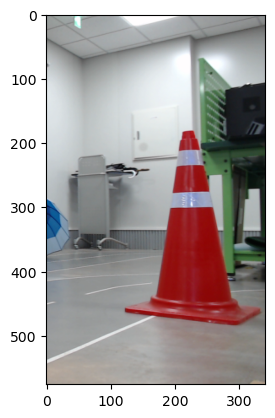

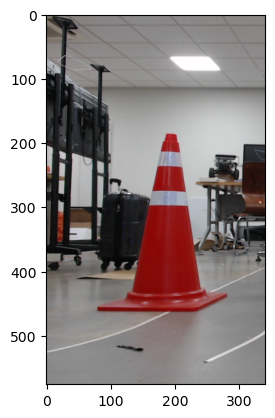

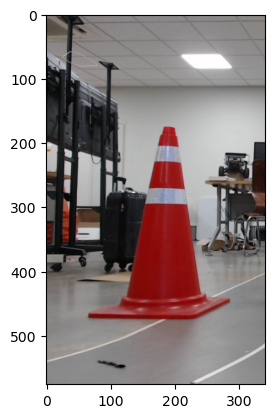

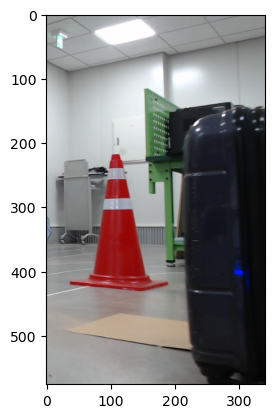

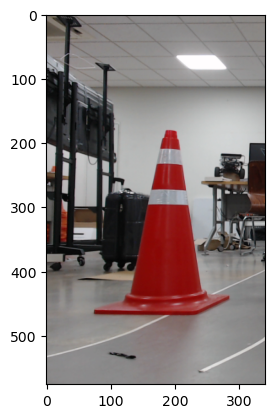

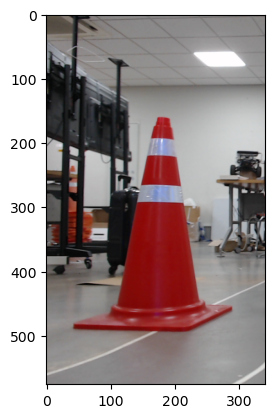

In [67]:
import matplotlib.pyplot as plt
import cv2
for i, img_ind in enumerate(sim_sort_ind):
    plt.figure(i)
    img = cv2.imread('n_images/'+str(img_ind)+'.png')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)

In [68]:
# print(sim_sort_ind)
# print(similarities_s[sim_sort_ind])
# get unique points
conf = {}
for index in sim_sort_ind:
    # print(len(features_ind[index]), features_ind[index])
    similarities_s = similarities[index]
    n_point = len(features_ind[index])
    for point in features_ind[index]:
        [s, n] = conf.get(tuple(point), [0,0])
        conf[tuple(point)] = [(s * n + similarities_s) / (n + 1), n + 1]
# sort confidence by value
conf_score = dict(sorted(conf.items(), key=lambda item: item[1], reverse=True))
conf_freq = dict(sorted(conf.items(), key=lambda item: item[1][1], reverse=True))

k = list(conf_score.keys())
v = list(conf_score.values())
print(k)
print(v)

K = list(conf_freq.keys())
V = list(conf_freq.values())
print(K)
print(V)

[(-0.5, -5.5, 0.0), (1.25, -7.25, 0.0), (-2.75, -2.5, 0.0), (1.25, -7.0, 0.0), (1.5, -7.0, 0.0), (-2.75, -2.25, 0.0), (1.5, -7.25, 0.0), (1.5, -6.75, 0.0), (-2.5, -2.25, 0.0), (-2.5, -2.5, 0.0), (-2.75, -2.75, 0.0), (-1.75, -4.0, 0.0), (-1.5, -4.0, 0.0)]
[[12.3414682798375, 5], [11.375176685768906, 2], [11.335694968086804, 3], [11.311758040842316, 3], [11.311758040842316, 3], [11.291080505044997, 12], [11.184920750989136, 1], [11.184920750989136, 1], [10.950504596826013, 9], [10.735027422163057, 2], [10.707704144260788, 1], [10.707704144260788, 1], [10.707704144260788, 1]]
[(-2.75, -2.25, 0.0), (-2.5, -2.25, 0.0), (-0.5, -5.5, 0.0), (-2.75, -2.5, 0.0), (1.25, -7.0, 0.0), (1.5, -7.0, 0.0), (1.25, -7.25, 0.0), (-2.5, -2.5, 0.0), (1.5, -7.25, 0.0), (1.5, -6.75, 0.0), (-2.75, -2.75, 0.0), (-1.75, -4.0, 0.0), (-1.5, -4.0, 0.0)]
[[11.291080505044997, 12], [10.950504596826013, 9], [12.3414682798375, 5], [11.335694968086804, 3], [11.311758040842316, 3], [11.311758040842316, 3], [11.37517668576